# Parsho autophagy analysis

This notebook demonstrates a Parsho workflow from raw TIFF images through cell measurements and nucleus-centered, cell-shape-adapted radial autophagy-related aggregate analysis. It uses the package's segmentation, mask-filtering, plotting, and distribution functions directly. 

The filename convention used here is `C1-<name>` for TIFF image of nuclei, `C2-<name>` for TIFF image of aggregates, and `C3-<name>` for TIFF image of cell membrane. Adjust the paths and filename helpers if your images use another naming convention.

In [19]:
# Necessary imports.
from pathlib import Path
import numpy as np
import pandas as pd
from cellpose import core, models
import cellpose.utils as utils_cell

from parsho.distribution import (
    compute_nucleus_centered_distribution,
    nucleus_centroids_by_cell,
)
from parsho.utils import (
    radial_distributions_to_records
)
from parsho.maskfilters import (
    build_overlay,
    compute_cell_metrics,
    filter_cells_by_overlap,
    mask_overlay_to_transfected,
    subtract_nuclear_from_aggregate,
)
from parsho.plotting import (
    plot_aggregate_channel,
    plot_aggregate_channel_color,
    plot_aggregate_channel_color_labelled,
    plot_nucleus_centered_distribution,
    plot_segmentation_result,
)
from parsho.segmentation import (
    extract_masks,
    find_optimal_threshold,
    re_threshold_masks,
)
from parsho.img_utils import (
    load_image
)


## Configuration

Parameters configuration for the run including desired parameters for CellPose (edit the values in the next cell)

In [20]:
# Folder path to results and data. Change this to your own path if you are running the tutorial outside of the parsho package.
DATA_DIR = Path("/media/ograciac/light-roast/ograciac/MorroCells/DatasetsParsho/Autophagy")

# Parameters for the radial aggregate distribution analysis.
RADIAL_BINS = 10 # A value of 10 means that the radial distribution will be computed in 10 shape-adapted sections from the nucleus to the cell boundary.

# Whether to remove the nulcei or not
REMOVE_NUCLEI = True

# Common Cellpose parameters used for control images and the batch of images. For more information on these parameters, see the Cellpose documentation.
CELLPOSE_PARAMETERS = {
    "batch_size": 32,
    "diameter": None,  # Expected cell diameter in pixels.
    "flow_threshold": 0.4,
    "cellprob_threshold": -2.0,
    "min_size": 15, # Minimum expected size of cells in pixels. This is used to filter out small objects that are unlikely to be cells.
    "normalize": {"tile_norm_blocksize": 0},
}
GPU = core.use_gpu()

print(f"Using GPU: {GPU}")


Using GPU: True


In [21]:
# Load CellPoseSAM
model = models.CellposeModel(gpu=GPU)

## Image loading 

The aggregate channel is kept at its original intensity scale for quantitative measurements.

In [22]:
# Function to load image sets
def load_image_set(data_dir: Path, name: str) -> tuple[np.ndarray, ...]:
    """Load cell, aggregate, and nuclear channels for one image set."""
    img_cell = load_image(data_dir / f"C3-{name}") # Load the cell membrane channel (C3) image. Change the name if your images use a different name convention.
    img_aggregates = load_image(data_dir / f"C2-{name}") # Load the aggregates channel (C2) image. Change the name if your images use a different name convention.
    img_nuclei = load_image(data_dir / f"C1-{name}") # Load the cell nuclei channel (C1) image. Change the name if your images use a different name convention.
    return img_cell, img_aggregates, img_nuclei

## Walk through one image set

Before running the batch, inspect one complete image set. The following cells displays the Cellpose segmentation, binary channel masks, categorical overlay, filtered labeled overlay, and nucleus-centered shape-adapted radial diagnostic using the plotting functions provided by Parsho.
This can be used to quickly spot artifacts or inadecuate parameters.

In this notebook all images follow the same naming convention with `C1-<name>` for nuclei, `C2-<name>` for aggregates, and `C3-<name>` for cells. 

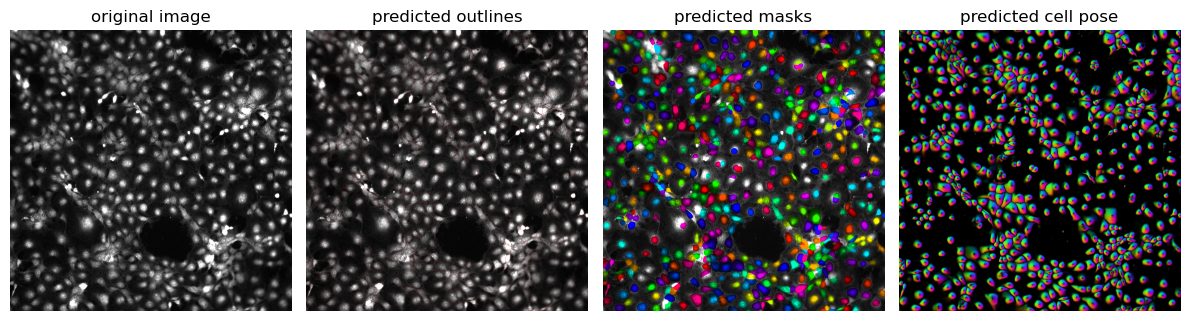

In [23]:
# Loading the data
example_name = "ebss_20x_lamp1_022.tif"
cell_channel, aggregates_channel, nuclei_channel = load_image_set(
    DATA_DIR, example_name
)

# Combine nuclei and cell for better recognition
img_two_channel = np.stack([cell_channel, nuclei_channel], axis=0)

# Obtain cell masks for the example image set (using Cellpose)
cell_masks, cell_flows,  _ = model.eval(img_two_channel, **CELLPOSE_PARAMETERS)
plot_segmentation_result(cell_channel, cell_masks, cell_flows)

Aggregates


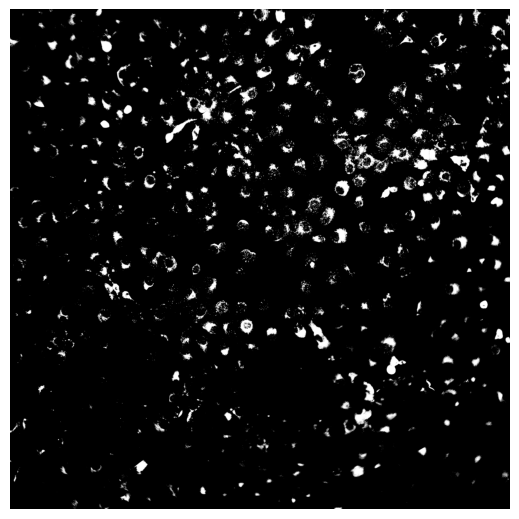

Nuclei


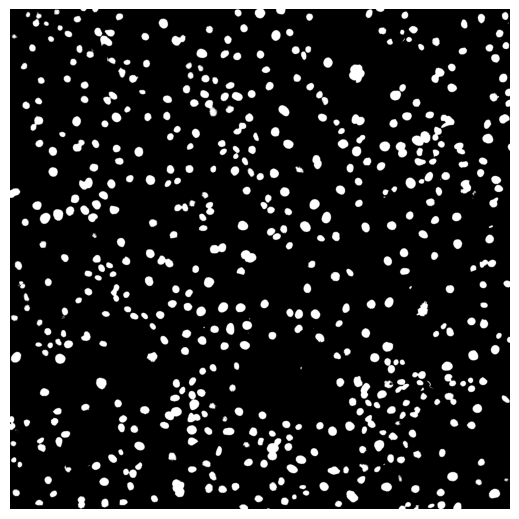

In [24]:
# Create masks for nuclear and aggregate channels using the optimal threshold
agg_binary, agg_labels, _ = extract_masks(
    aggregates_channel, cell_masks, min_size_px=2 
)
nuc_binary, nuc_labels, _ = extract_masks(
    nuclei_channel, cell_masks, method="otsu", min_size_px=5
)

print("Aggregates")
plot_aggregate_channel(agg_binary)
print("Nuclei")
plot_aggregate_channel(nuc_binary)


### Overlays

Plotting the overlays allows to visualize masks together.

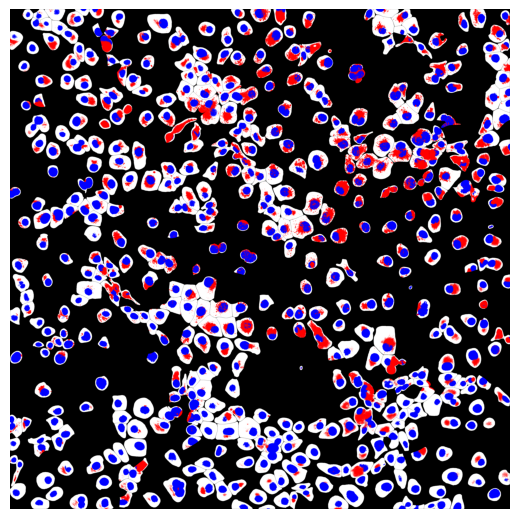

In [25]:
# Overlay the masks and outlines on the original image for visualization
outlines = utils_cell.masks_to_outlines(cell_masks)
overlay = build_overlay(
    cell_masks, nuc_labels, agg_labels, outlines
)
plot_aggregate_channel_color(overlay)

### Cell labels

Each masked cell gets a unique label to allow matching the images to the extracted data. 

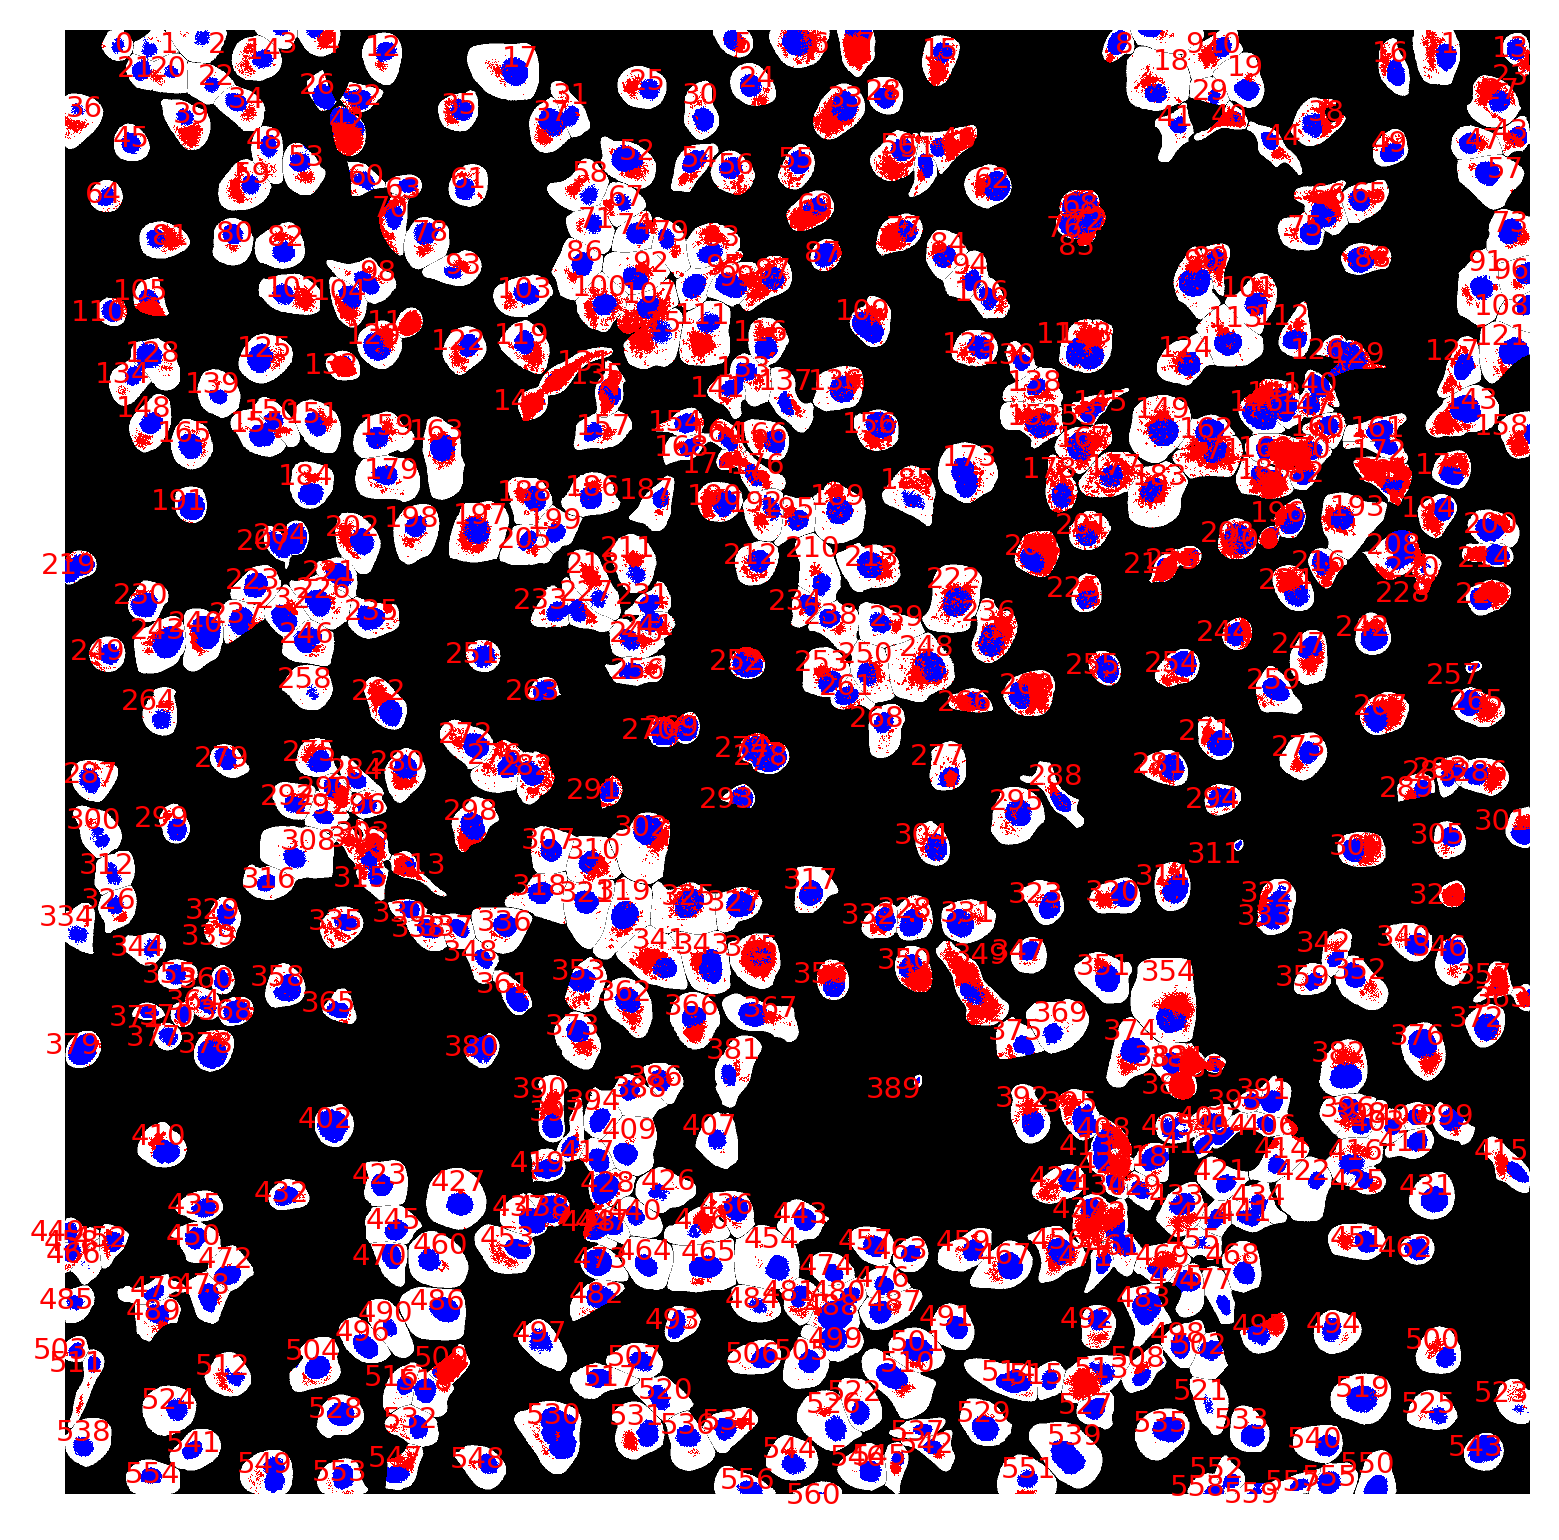

In [26]:
# Keep cells that overlap the nuclear mask and number them in a filtered overlay
labels = filter_cells_by_overlap(
    cell_masks, nuc_labels
)
filtered_overlay = mask_overlay_to_transfected(
    overlay, cell_masks, labels
)

records: list[dict]   = []
text_mapping = {}
reverse_text_mapping = {}
for jj, metrics in enumerate(compute_cell_metrics(cell_masks, nuc_labels, agg_labels, labels)):
    records.append({
        "cell num":  jj,
        "cell area": metrics.cell_area,
        "agg area":  metrics.agg_area,
        "nuc area":  metrics.nuc_area,
        "jaccard":   metrics.jaccard,
        "cell aspect ratio": metrics.cell_aspect_ratio,
        "cell circularity": metrics.cell_circularity,
        "agg aspect ratio": metrics.agg_aspect_ratio,
        "agg circularity": metrics.agg_circularity
    })
    text_mapping[metrics.label] = jj
    reverse_text_mapping[jj] = metrics.label
    
plot_aggregate_channel_color_labelled(
    filtered_overlay, cell_masks, text_mapping
)

## Radial distribution analysis

The next section shows how to analyze the localization of the aggregates using the nucleous as cell center.
The module computes both pixels and cumulative intensity distributions. [ref1](https://link.springer.com/article/10.15252/embr.201541382) ,[ref2](https://www.nature.com/articles/s41467-024-44957-1)

In [27]:

# Radial distribution analysis for the transfected cells
radial_intensity = aggregates_channel.copy()

if REMOVE_NUCLEI:
    radial_intensity[nuc_binary != 0] = 0 # Filter out points overlapping with the nucleus

nucleus_centroids = nucleus_centroids_by_cell(
    cell_masks, nuc_binary, cell_labels=labels
)
radial_distributions = compute_nucleus_centered_distribution(
    cell_masks,
    nucleus_centroids,
    agg_binary,
    radial_intensity,
    radial_bins=RADIAL_BINS,
    cell_labels=list(nucleus_centroids),
)

Available cell display labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215

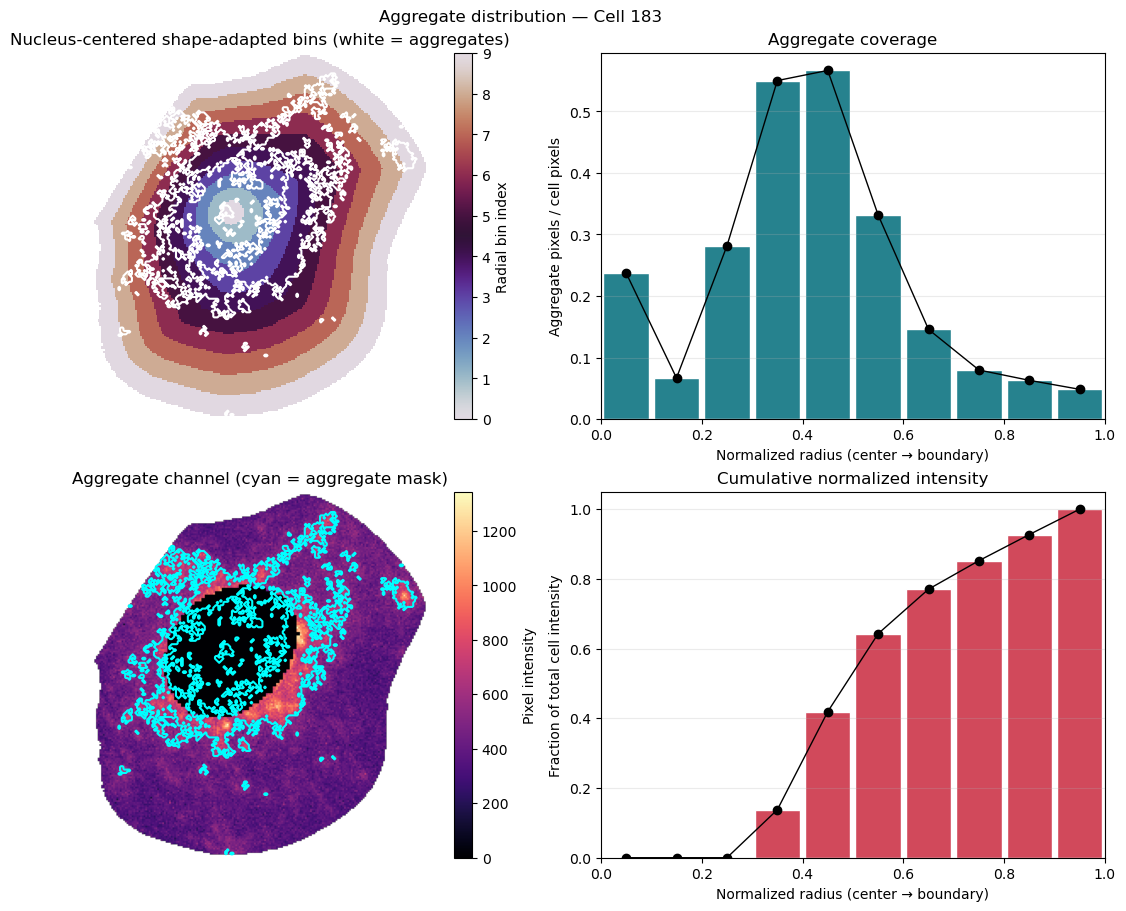

In [28]:
# Choose an available display label; replace it with another from this list.
available_labels = [number for number, label in reverse_text_mapping.items() if label in radial_distributions]
print("Available cell display labels:", available_labels)
example_label = 183 #next(iter(available_labels), None)
if example_label is None:
    print("No radial data: inspect cell filtering and nucleus detection.")
else:
    internal_label = reverse_text_mapping[example_label]
    plot_nucleus_centered_distribution(
        cell_masks,
        agg_binary,
        radial_intensity,
        radial_distributions[internal_label],
        cell_name=f"Cell {example_label}"
    )


In [29]:
# Show results for all cells
pd.DataFrame(records)

,cell num,cell area,agg area,nuc area,jaccard,cell aspect ratio,cell circularity,agg aspect ratio,agg circularity
0,0,7774,70,1392,0.009004,1.059,0.859,inf,1.711333
1,1,9604,129,1853,0.013432,1.413,0.712,inf,7.128867
2,2,15550,173,1792,0.011125,1.596,0.696,inf,1.156526
3,3,5891,0,832,0.000000,2.054,0.600,0.0,0.000000
4,4,9602,2507,1292,0.261091,1.508,0.776,inf,6.380864
...,...,...,...,...,...,...,...,...,...
556,556,11830,0,2760,0.000000,2.364,0.581,0.0,0.000000
557,557,6770,0,1780,0.000000,2.226,0.586,0.0,0.000000
558,558,5788,0,1556,0.000000,1.592,0.666,0.0,0.000000
559,559,4570,0,1038,0.000000,3.477,0.493,0.0,0.000000


In [30]:
# Show results for Radial distribution analysis for all cells
records_radial = radial_distributions_to_records(
    {example_name: radial_distributions}
)
# Change the label to transfected cells
for record in records_radial:
    record["cell_label"] = text_mapping[record["cell_label"]]

# Display results
radial_df = pd.DataFrame(records_radial)
display(radial_df)

,image_id,cell_label,centroid_row,centroid_column,radial_bin,radius_start,radius_end,section_size_pixels,aggregate_pixels,aggregate_present,aggregate_fraction,aggregate_share,intensity_sum,intensity_mean,intensity_share,cumulative_normalized_intensity
0,ebss_20x_lamp1_022.tif,0,52.683908,167.718391,0,0.0,0.1,72,0,False,0.0,0.0,0.0,0.0,0.0,0.0
1,ebss_20x_lamp1_022.tif,0,52.683908,167.718391,1,0.1,0.2,216,0,False,0.0,0.0,0.0,0.0,0.0,0.0
2,ebss_20x_lamp1_022.tif,0,52.683908,167.718391,2,0.2,0.3,362,0,False,0.0,0.0,0.0,0.0,0.0,0.0
3,ebss_20x_lamp1_022.tif,0,52.683908,167.718391,3,0.3,0.4,515,0,False,0.0,0.0,0.0,0.0,0.0,0.0
4,ebss_20x_lamp1_022.tif,0,52.683908,167.718391,4,0.4,0.5,676,0,False,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5605,ebss_20x_lamp1_022.tif,560,4652.957143,2405.128571,5,0.5,0.6,362,0,False,0.0,0.0,0.0,0.0,0.0,0.0
5606,ebss_20x_lamp1_022.tif,560,4652.957143,2405.128571,6,0.6,0.7,504,0,False,0.0,0.0,0.0,0.0,0.0,0.0
5607,ebss_20x_lamp1_022.tif,560,4652.957143,2405.128571,7,0.7,0.8,737,0,False,0.0,0.0,0.0,0.0,0.0,0.0
5608,ebss_20x_lamp1_022.tif,560,4652.957143,2405.128571,8,0.8,0.9,1065,0,False,0.0,0.0,0.0,0.0,0.0,0.0
